# Week 2 Assignment - IMDb Sentiment Analyser
### WnCC Machine Learning Learner Space 2026

---

In this notebook you will build a **complete sentiment analysis pipeline** - from raw text to a trained neural network - entirely from scratch.

**Your pipeline:**
```
Raw Text → Clean → Tokenise → BoW / TF-IDF → Logistic Regression (baseline)
                                            → MLP (neural network)
                                            → Evaluate with F1, Confusion Matrix
```

**Rules:**
- You may use `numpy`, `matplotlib`, `sklearn` for utilities
- For the MLP section, use **PyTorch** (or NumPy if you prefer)
- Do NOT just call `sklearn.Pipeline` and call it done. Implement the concepts.
- Every `# YOUR CODE HERE` block must be filled in

---
**Run the setup cell first. Then work top to bottom.**

In [1]:
# ========== SETUP ==========
# Run this cell first - it installs dependencies and downloads the dataset

!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
import re
import math
from collections import Counter, defaultdict
from datasets import load_dataset

# Load IMDb dataset
print('Loading IMDb dataset...')
dataset = load_dataset('stanfordnlp/imdb', trust_remote_code=True)

# Use a subset for speed
N_TRAIN = 5000
N_TEST  = 1000

# Shuffle and select subsets before extracting lists (we made a similar change in assignment 1)
train_subset = dataset['train'].shuffle(seed=42).select(range(N_TRAIN))
test_subset  = dataset['test'].shuffle(seed=42).select(range(N_TEST))

# Extract texts and labels
train_texts  = train_subset['text']
train_labels = train_subset['label']
test_texts   = test_subset['text']
test_labels  = test_subset['label']

print(f'Loaded {N_TRAIN} training and {N_TEST} test reviews.')
print(f'Sample review: "{train_texts[0][:120]}..."')
print(f'Label: {"Positive" if train_labels[0] == 1 else "Negative"}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading IMDb dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 5000 training and 1000 test reviews.
Sample review: "There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. ..."
Label: Positive


---
## Part 1 - Text Preprocessing

Raw text is messy. Before any model can use it, we need to:
1. **Lowercase** everything (so "Good" and "good" are the same word)
2. **Remove HTML tags** (IMDb reviews often contain `<br />` etc.)
3. **Remove punctuation** (most of it doesn't carry sentiment)
4. **Tokenise** - split into individual words
5. **Remove stopwords** - extremely common words ("the", "is", "a") that add noise

> 💡 Notice: we are NOT removing all punctuation blindly. Negation words like "n't" matter!

In [2]:
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'he', 'him', 'his',
    'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its',
    'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because',
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'than',
    'too', 'very', 's', 't', 'can', 'will', 'just', 'should', "should've", 'now',
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn',
    "wouldn't"
])

def preprocess(text):
    """
    Clean and tokenise a raw review string.
    Returns a list of tokens (strings).
    """
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Step 3: Keep only letters and spaces (remove punctuation, numbers)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 4: Tokenise by splitting on whitespace
    tokens = text.split()
    # Step 5: Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

# Preprocess all reviews
print('Preprocessing reviews...')
train_tokens = [preprocess(t) for t in train_texts]
test_tokens  = [preprocess(t) for t in test_texts]

print('Sample tokens:', train_tokens[0][:15])

Preprocessing reviews...
Sample tokens: ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler']


---
## Part 2 - Bag-of-Words Vectoriser

Build a vocabulary from the training data, then convert each review into a count vector.

**Your task:** Complete the `BagOfWords` class below.

In [3]:
class BagOfWords:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}       # word → index
        self.vocab_size = 0

    def fit(self, token_lists):
        """
        Build vocabulary from training data.
        Keep only the top `max_vocab` most frequent words.
        """
        # Count all word frequencies across all token_lists
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        # Take the top max_vocab words
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
        self.vocab_size = len(self.vocab)
        print(f'Vocabulary built: {self.vocab_size} words')
        return self

    def transform(self, token_lists):
        """
        Convert a list of token lists into a count matrix.
        Output shape: (num_documents, vocab_size)
        """
        # YOUR CODE HERE
        # Hint: for each token_list, create a vector of size vocab_size
        # where index i = count of vocab word i in this document
        matrix = np.zeros((len(token_lists), self.vocab_size), dtype=np.float32)
        for doc_idx, tokens in enumerate(token_lists):
          for token in tokens:
            if token in self.vocab:
              matrix[doc_idx, self.vocab[token]] += 1
        return matrix

    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


bow = BagOfWords(max_vocab=5000)
X_train_bow = bow.fit_transform(train_tokens)
X_test_bow  = bow.transform(test_tokens)
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f'X_train_bow shape: {X_train_bow.shape}')  # (5000, 5000)
print(f'Sparsity: {(X_train_bow == 0).mean():.1%} zeros')

Vocabulary built: 5000 words
X_train_bow shape: (5000, 5000)
Sparsity: 98.4% zeros


---
## Part 3 - TF-IDF Vectoriser

Improve on raw counts by weighting words by how informative they are.

**Your task:** Complete the `TFIDF` class.

In [4]:
class TFIDF:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}
        self.idf = None

    def fit(self, token_lists):
        # Build vocab (same as BoW)
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}

        # Compute IDF for each vocab word
        # IDF(word) = log((1 + N) / (1 + df(word))) + 1  [smoothed version]
        # where N = number of documents, df = number of docs containing the word
        N = len(token_lists)
        df = np.zeros(len(self.vocab), dtype=np.float32)

        # YOUR CODE HERE
        # Count how many documents each word appears in
        for tokens in token_lists:
          for token in tokens:
            if token in self.vocab:
              df[self.vocab[token]] += 1

        self.idf = np.log((1 + N) / (1 + df)) + 1
        print(f'TF-IDF vocab size: {len(self.vocab)}')
        return self

    def transform(self, token_lists):
        # YOUR CODE HERE
        # Step 1: Compute TF matrix (normalised count per document)
        # Step 2: Multiply elementwise by IDF weights
        # Step 3: L2-normalise each row
        tf = np.zeros((len(token_lists), len(self.vocab)), dtype=np.float32)

        for doc_idx, tokens in enumerate(token_lists):
          if len(tokens) == 0:
            continue
          for token in tokens:
            if token in self.vocab:
              tf[doc_idx, self.vocab[token]] += 1

          tf[doc_idx] /= len(tokens)

        tfidf = tf * self.idf
        norms = np.linalg.norm(tfidf, axis=1, keepdims=True)
        norms[norms == 0] = 1

        tfidf /= norms

        return tfidf


    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


tfidf = TFIDF(max_vocab=5000)
X_train_tfidf = tfidf.fit_transform(train_tokens)
X_test_tfidf  = tfidf.transform(test_tokens)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')

TF-IDF vocab size: 5000
X_train_tfidf shape: (5000, 5000)


---
## Part 4 - Evaluation Toolkit

Implement the metrics from scratch. Then use them everywhere.

In [5]:
def confusion_matrix(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]] for binary classification."""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[tn, fp],
                     [fn, tp]])


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  tp = cm[1,1]
  fp = cm[0,1]

  return tp / (tp + fp + 1e-8)

def recall(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  tp = cm[1,1]
  fn = cm[1,0]

  return tp / (tp + fn + 1e-8)

def f1_score(y_true, y_pred):
  p = precision(y_true, y_pred)
  r = recall(y_true, y_pred)

  return 2 * p * r / (p + r + 1e-8)

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg (pred)', 'Pos (pred)'])
    ax.set_yticklabels(['Neg (true)', 'Pos (true)'])
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(title, fontsize=14, pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def evaluate(y_true, y_pred, name='Model'):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy(y_true, y_pred)
    p   = precision(y_true, y_pred)
    r   = recall(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall   : {r:.4f}')
    print(f'F1 Score : {f1:.4f}')
    plot_confusion_matrix(cm, title=name)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

print('Evaluation toolkit ready!')

Evaluation toolkit ready!


---
## Part 5 - Logistic Regression Baseline

A logistic regression classifier on TF-IDF features. This is your **baseline** - your MLP must beat this.

Training Logistic Regression baseline...

===== Logistic Regression (TF-IDF Baseline) =====
Accuracy : 0.8520
Precision: 0.8257
Recall   : 0.8832
F1 Score : 0.8535


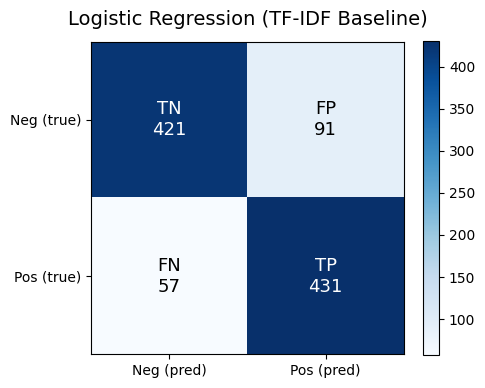

In [6]:
from sklearn.linear_model import LogisticRegression

print('Training Logistic Regression baseline...')
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_metrics = evaluate(y_test, y_pred_lr, name='Logistic Regression (TF-IDF Baseline)')

---
## Part 6 - MLP Classifier with PyTorch

Now build a Multi-Layer Perceptron that takes TF-IDF vectors as input and classifies sentiment.

**Architecture:**
```
Input (5000) → Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear(2) → Softmax
```

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to PyTorch tensors
X_tr = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ===== Define the MLP =====
class SentimentMLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden2, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.net(x)

model     = SentimentMLP(input_dim=5000)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentMLP(
  (net): Sequential(
    (0): Linear(in_features=5000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
    (7): Softmax(dim=1)
  )
)

Total trainable parameters: 1,313,410


Epoch 01/15  Loss: 0.6083  Train Acc: 0.7518
Epoch 02/15  Loss: 0.3996  Train Acc: 0.9178
Epoch 03/15  Loss: 0.3586  Train Acc: 0.9566
Epoch 04/15  Loss: 0.3401  Train Acc: 0.9774
Epoch 05/15  Loss: 0.3312  Train Acc: 0.9840
Epoch 06/15  Loss: 0.3272  Train Acc: 0.9882
Epoch 07/15  Loss: 0.3253  Train Acc: 0.9890
Epoch 08/15  Loss: 0.3245  Train Acc: 0.9896
Epoch 09/15  Loss: 0.3234  Train Acc: 0.9904
Epoch 10/15  Loss: 0.3227  Train Acc: 0.9912
Epoch 11/15  Loss: 0.3224  Train Acc: 0.9914
Epoch 12/15  Loss: 0.3220  Train Acc: 0.9916
Epoch 13/15  Loss: 0.3217  Train Acc: 0.9918
Epoch 14/15  Loss: 0.3217  Train Acc: 0.9918
Epoch 15/15  Loss: 0.3216  Train Acc: 0.9918


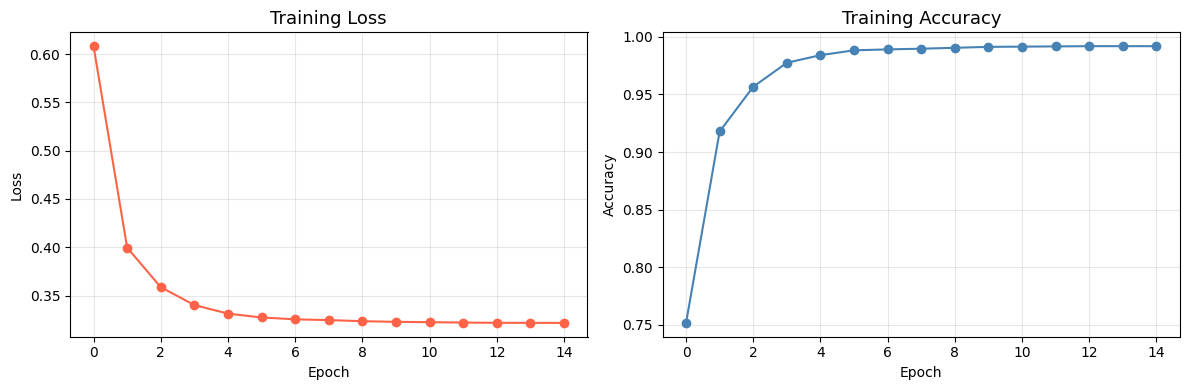

In [8]:
# ===== Training Loop =====
EPOCHS = 15
train_losses = []
train_accs   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    avg_loss = epoch_loss / total
    avg_acc  = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    print(f'Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.4f}  Train Acc: {avg_acc:.4f}')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, marker='o', color='tomato')
ax1.set_title('Training Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, marker='o', color='steelblue')
ax2.set_title('Training Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


===== MLP (TF-IDF Input) =====
Accuracy : 0.8440
Precision: 0.8458
Recall   : 0.8320
F1 Score : 0.8388


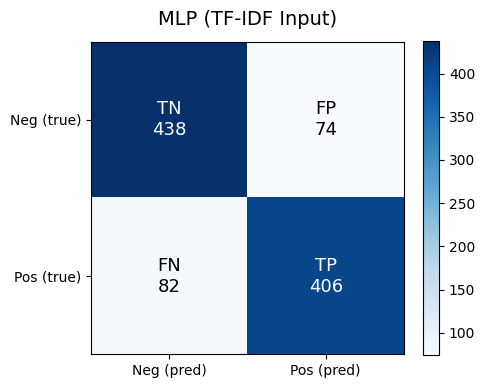

In [9]:
# ===== Evaluate MLP on Test Set =====
model.eval()
with torch.no_grad():
    logits = model(X_te)
    y_pred_mlp = logits.argmax(dim=1).numpy()

mlp_metrics = evaluate(y_test, y_pred_mlp, name='MLP (TF-IDF Input)')

In [10]:
# ===== Sanity Check =====
print('========== SANITY CHECK ==========')
print(f'Logistic Regression F1: {lr_metrics["f1"]:.4f}')
print(f'MLP F1:                 {mlp_metrics["f1"]:.4f}')

if mlp_metrics['f1'] > 0.70:
    print('✅ PASS: MLP F1 > 0.70')
else:
    print('❌ MLP F1 is below 0.70. Try training for more epochs, tuning hidden sizes, or adjusting learning rate.')

# Quick demo
print('\n===== DEMO =====')
demo_reviews = [
    'This movie was absolutely brilliant. The acting was superb and the story was moving.',
    'Terrible film. Boring, predictable, and a complete waste of time.'
]
for rev in demo_reviews:
    tokens  = preprocess(rev)
    vec     = tfidf.transform([tokens])
    x_demo  = torch.tensor(vec, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logit  = model(x_demo)
        prob   = torch.softmax(logit, dim=1)
        pred   = prob.argmax().item()
    label = '😊 Positive' if pred == 1 else '😞 Negative'
    conf  = prob[0, pred].item()
    print(f'  Review: "{rev[:60]}..."')
    print(f'  → Prediction: {label}  (confidence: {conf:.2%})\n')

========== SANITY CHECK ==========
Logistic Regression F1: 0.8535
MLP F1:                 0.8388
✅ PASS: MLP F1 > 0.70

===== DEMO =====
  Review: "This movie was absolutely brilliant. The acting was superb a..."
  → Prediction: 😊 Positive  (confidence: 73.11%)

  Review: "Terrible film. Boring, predictable, and a complete waste of ..."
  → Prediction: 😞 Negative  (confidence: 73.11%)



---
## Part 7 - Reflection (Required)

**Fill in this Markdown cell with your answers before submitting.**

1. **What was the F1 score of your Logistic Regression baseline?**  
   The Logistic Regression baseline achieved an F1 score of 0.8535.
2. **What was the F1 score of your MLP?**  
   The MLP achieved an F1 score of 0.8388.

3. **Did the MLP outperform the baseline? By how much? Why do you think that is?**  
   No. The MLP performed slightly worse than the Logistic Regression baseline by about 0.0147 F1. Logistic Regression works very well with TF-IDF features because they are already highly informative, while the MLP requires more data and tuning to achieve better generalization.

4. **Look at your confusion matrix. Where does your model make the most mistakes - false positives or false negatives? What kind of reviews do you think it gets wrong?**  
   The model made slightly more false positive predictions than false negatives. Most errors were on reviews with mixed opinions, subtle sentiment, or sarcasm where the overall sentiment was difficult to identify.

5. **The model is still using TF-IDF as input. What is the fundamental limitation here? What would need to change to build a truly "understanding" model?**  
   TF-IDF treats text as a collection of independent words and ignores word order and context. A model with learned embeddings and contextual architectures such as LSTMs or Transformers would capture semantic meaning more effectively.

---
**Submit your completed notebook to the WnCC submission form. Good luck! 🚀**